In [1]:
# Moja pierwsza komórka
print("Witaj w Jupyter Notebook!")
2 + 2


Witaj w Jupyter Notebook!


4

# Laboratorium 2 — Eksploracja danych
**Autor:** [Kacper]
**Data:** [16.03.2026]
## Cel
Wczytanie i eksploracja datasetu z danymi z restauracji.


## Krok 1: Import bibliotek

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Krok 2: Wczytanie danych
Dataset: rachunki z restauracji (244 obserwacje, 7 zmiennych).


In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv')
print(f"Dane wczytane: {df.shape[0]} wierszy, {df.shape[1]} kolumn")

Dane wczytane: 244 wierszy, 7 kolumn


 ## Krok 3: Poznanie danych

In [4]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [7]:
df.tail()

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    str    
 3   smoker      244 non-null    str    
 4   day         244 non-null    str    
 5   time        244 non-null    str    
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 13.5 KB


In [9]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [10]:
df.dtypes

total_bill    float64
tip           float64
sex               str
smoker            str
day               str
time              str
size            int64
dtype: object

In [12]:
df.columns.tolist()

['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']

## Wnioski z eksploracji
- Dataset zawiera 244 wierszy i 7 kolumn
- Kolumny numeryczne 3
- Kolumny tekstowe 4
- Brakujące wartości : null
- Średni rachunek wynosi 19.79 $

## Pytania biznesowe
Pytanie 1: Jaki był najwyższy rachunek?

In [24]:
print(df['total_bill'].max())


50.81


Pytanie 2: Ile rachunków obsłużono w każdym dniu tygodnia?

In [25]:
print(df['day'] .value_counts())

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


Pytanie 3: Jaki jest średni napiwek dla palaczy vs niepalących?

In [26]:
print(df.groupby('smoker')['tip'].mean())

smoker
No     2.991854
Yes    3.008710
Name: tip, dtype: float64


Pytanie 4:Jaki procent rachunku stanowi napiwek (średnio)?

In [28]:
df['tip_percent'] = df['tip'] / df['total_bill'] * 100
print(df['tip_percent'].mean())


16.08025817225047


Pytanie 5: Który dzień + pora (Lunch/Dinner) przynosi najwyższe rachunki?

In [29]:
print(df.groupby(['day', 'time'])['total_bill'].mean())

day   time  
Fri   Dinner    19.663333
      Lunch     12.845714
Sat   Dinner    20.441379
Sun   Dinner    21.410000
Thur  Dinner    18.780000
      Lunch     17.664754
Name: total_bill, dtype: float64


Ćwiczenie 4: Pierwszy wykres + commit

Krok 1- wykres

## wizualizacja

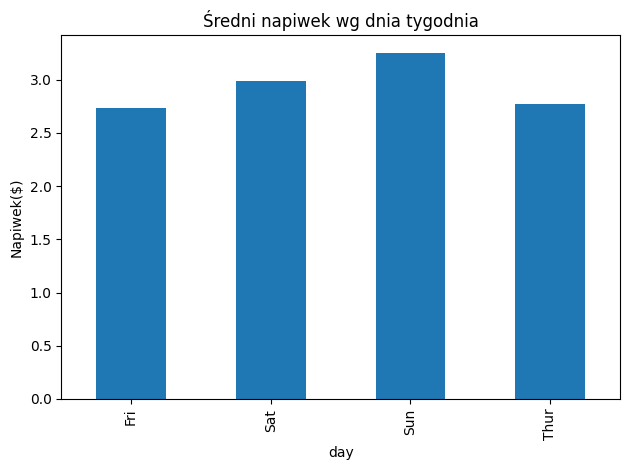

In [33]:
#Średni napiwek wg dnia tygodnia
df.groupby('day')['tip'].mean().plot(kind='bar', title='Średni napiwek wg dnia tygodnia')
plt.ylabel('Napiwek($)')
plt.tight_layout()
plt.show()